In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
import warnings
from matplotlib import gridspec

FemTemp: circ=3.4992, ultra=0.0491, ratio=71.25
MaleTemp: circ=3.5628, ultra=0.0793, ratio=44.91
FemAct: circ=3.5804, ultra=0.0812, ratio=44.08
MaleAct: circ=3.4411, ultra=0.1107, ratio=31.08


/tmp/ipykernel_383/2015549718.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


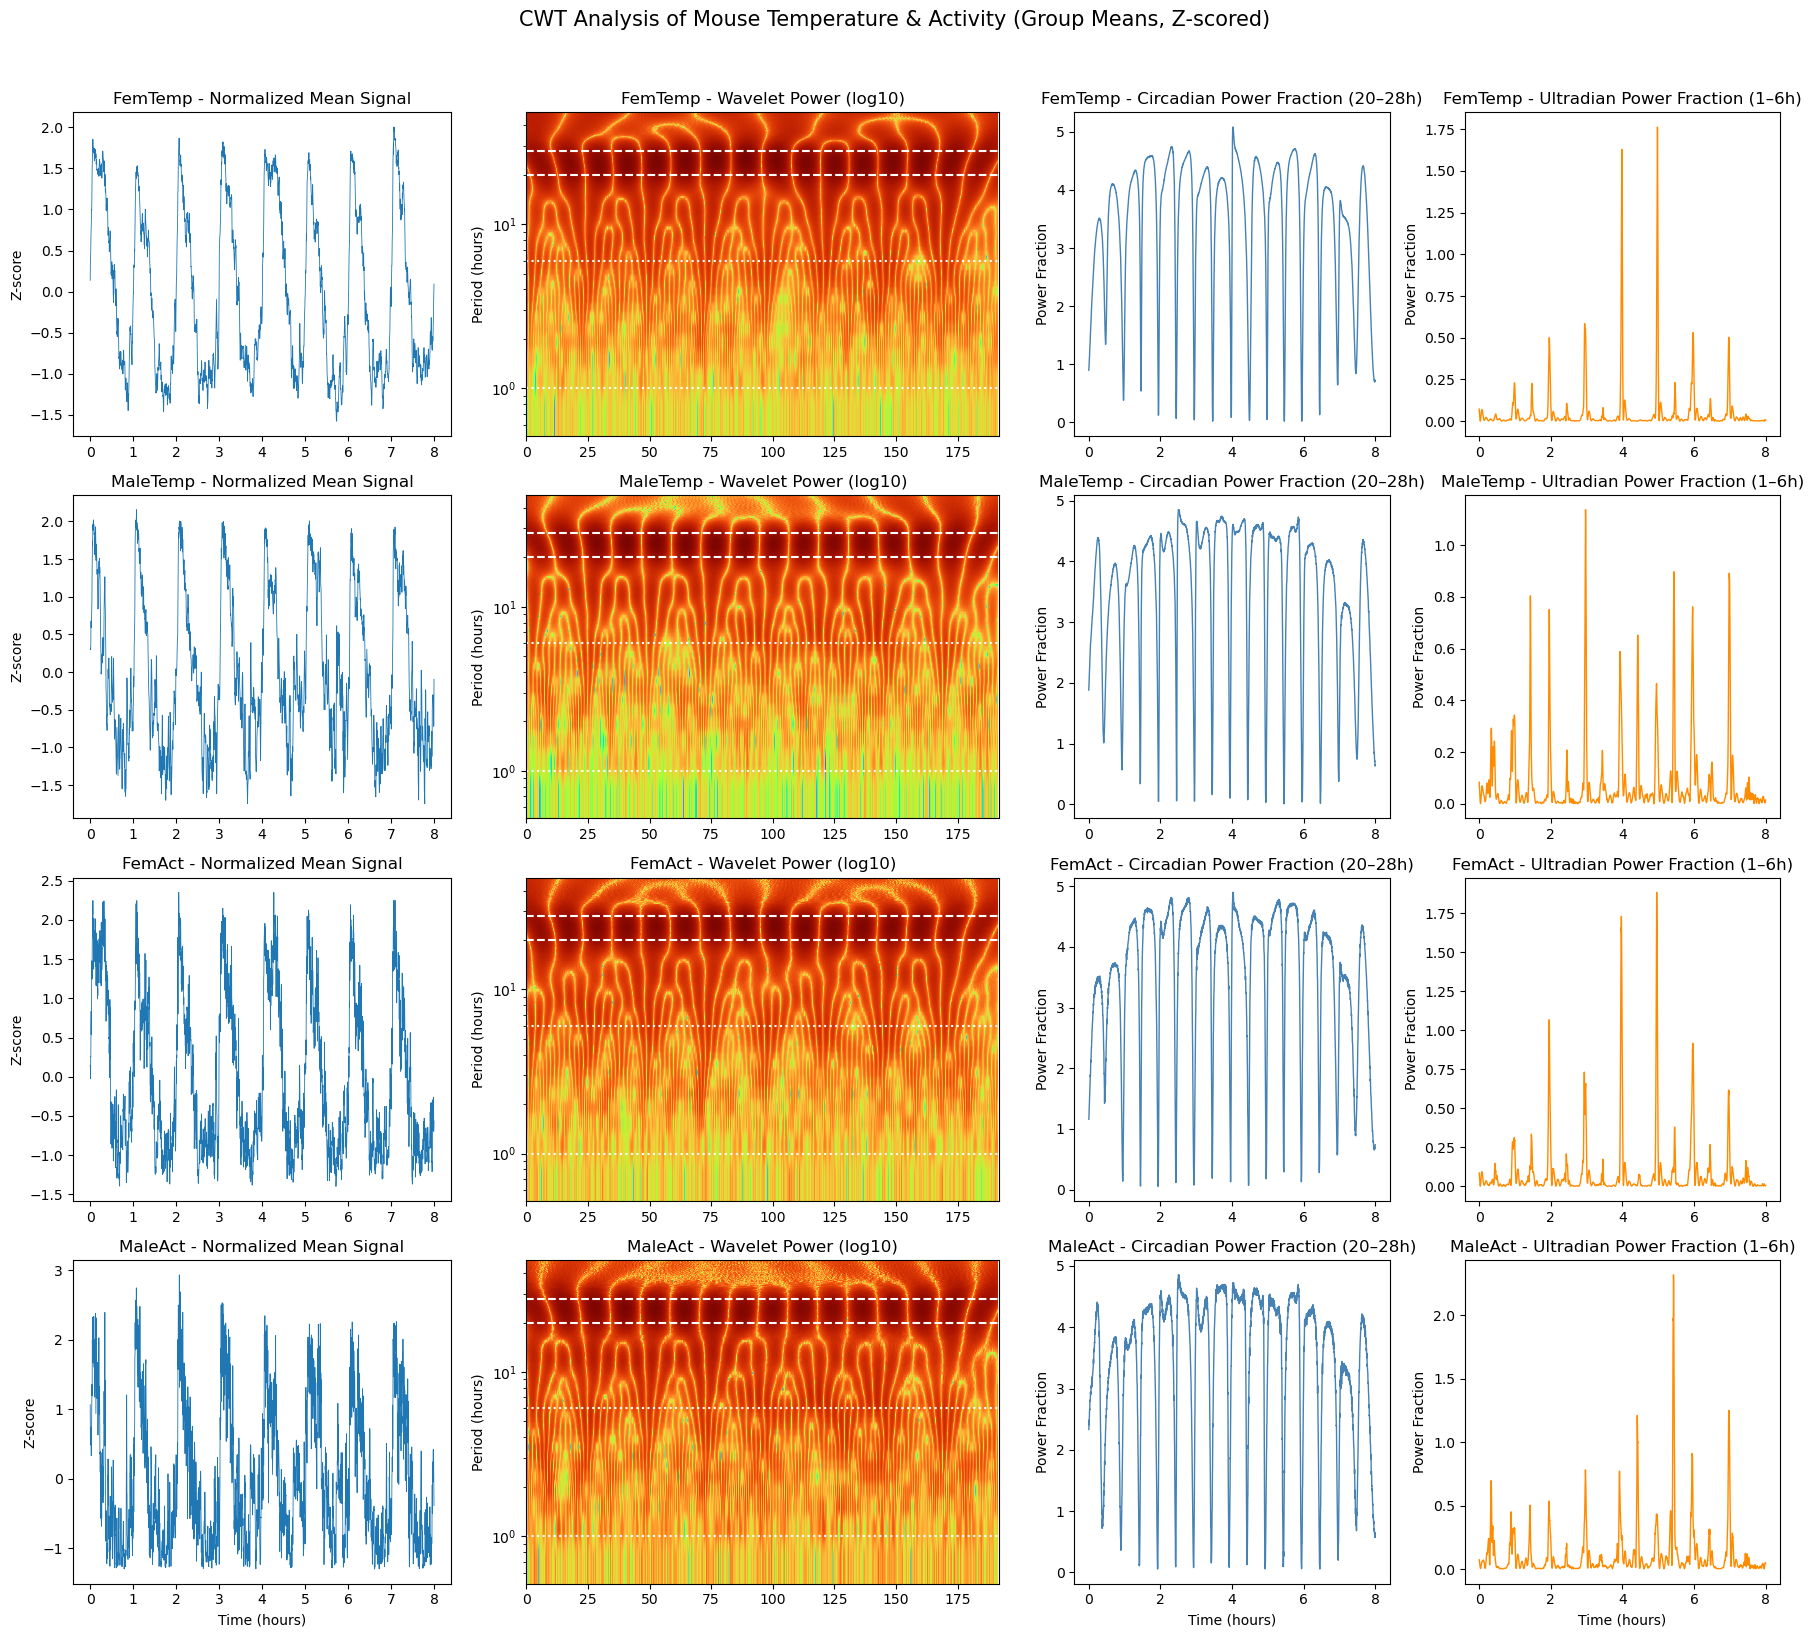

In [14]:
# Define data path and sheets to analyze
xlsx_path = "../data/mice_data.xlsx"
sheets = ["FemTemp", "FemAct", "MaleTemp", "MaleAct"]

warnings.filterwarnings("ignore", category=RuntimeWarning)
orig_dt = 1.0 / 60.0      # 1 min sampling -> hours
downsample_minutes = 5    # downsample to 5-min bins
ds_factor = downsample_minutes
dt = orig_dt * ds_factor
min_period = 0.5
max_period = 48.0
circadian_range = (20.0, 28.0)
ultradian_range = (1.0, 6.0)
wavelet_name = "morl"

# === Define scales ===
candidate_scales = np.arange(1, 1200)
freqs_candidate = pywt.scale2frequency(wavelet_name, candidate_scales) / dt
periods_candidate = 1.0 / freqs_candidate
valid_idx = np.where((periods_candidate >= min_period) & (periods_candidate <= max_period))[0]
min_scale = candidate_scales[valid_idx[0]]
max_scale = candidate_scales[valid_idx[-1]]
num_scales = 120
scales = np.linspace(min_scale, max_scale, num_scales)

results = {}

# === Loop through sheets ===
for sheet in sheets:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
    # Drop non-numeric column (time)
    df = df.drop(columns=[col for col in df.columns if 'time' in col.lower()])

    # Convert all numeric columns to float and average across them (group mean)
    df = df.apply(pd.to_numeric, errors='coerce')
    sig = df.mean(axis=1).to_numpy()

    # Downsample to 5-min bins
    n_orig = len(sig)
    n_trim = (n_orig // ds_factor) * ds_factor
    sig_trim = sig[:n_trim]
    sig_ds = sig_trim.reshape(-1, ds_factor).mean(axis=1)

    # --- Z-score normalization ---
    sig_norm = (sig_ds - np.mean(sig_ds)) / np.std(sig_ds)

    # --- Detrend ---
    signal_dt = detrend(sig_norm, type='linear')

    # --- Continuous Wavelet Transform ---
    coeffs, freqs = pywt.cwt(signal_dt, scales, wavelet_name, sampling_period=dt)
    power = np.abs(coeffs)**2
    periods = 1.0 / freqs

    # --- Band masks ---
    circ_mask = (periods >= circadian_range[0]) & (periods <= circadian_range[1])
    ultra_mask = (periods >= ultradian_range[0]) & (periods <= ultradian_range[1])

    # --- Power in each band ---
    circ_power_t = np.nanmean(power[circ_mask, :], axis=0)
    ultra_power_t = np.nanmean(power[ultra_mask, :], axis=0)
    total_power_t = np.nanmean(power, axis=0)

    # --- Relative power ---
    circ_frac_t = circ_power_t / (total_power_t + 1e-12)
    ultra_frac_t = ultra_power_t / (total_power_t + 1e-12)

    circ_total = np.nanmean(circ_frac_t)
    ultra_total = np.nanmean(ultra_frac_t)
    ratio = circ_total / (ultra_total + 1e-12)

    time_hours = np.arange(len(sig_ds)) * dt

    results[sheet] = {
        "time_hours": time_hours,
        "signal": sig_norm,
        "periods": periods,
        "power": power,
        "circ_frac_t": circ_frac_t,
        "ultra_frac_t": ultra_frac_t,
        "circ_total": circ_total,
        "ultra_total": ultra_total,
        "ratio": ratio
    }

    print(f"{sheet}: circ={circ_total:.4f}, ultra={ultra_total:.4f}, ratio={ratio:.2f}")

# === Plot results ===
num = len(sheets)
fig = plt.figure(constrained_layout=True, figsize=(18, 3*num + 4))
spec = gridspec.GridSpec(
    ncols=4, nrows=num, figure=fig, width_ratios=[1.2, 1.5, 1.0, 1.0]
)

for i, sheet in enumerate(sheets):
    r = results[sheet]
    t = r["time_hours"]
    sig = r["signal"]
    power = r["power"]
    periods_plot = r["periods"]
    t_days = t / 24.0

    # Restrict to visible range
    pmask = (periods_plot >= min_period) & (periods_plot <= max_period)
    power_plot = power[pmask, :]
    periods_plot_sel = periods_plot[pmask]

    # === Column 1: normalized signal ===
    ax0 = fig.add_subplot(spec[i, 0])
    ax0.plot(t_days, sig, lw=0.6)
    ax0.set_title(f"{sheet} - Normalized Mean Signal")
    ax0.set_ylabel("Z-score")
    if i == num - 1:
        ax0.set_xlabel("Time (hours)")

    # === Column 2: wavelet power ===
    ax1 = fig.add_subplot(spec[i, 1])
    extent = [t[0], t[-1], periods_plot_sel.min(), periods_plot_sel.max()]
    im = ax1.imshow(
        np.log10(power_plot + 1e-12),
        aspect='auto', extent=extent, origin='lower', cmap='turbo'
    )
    ax1.set_yscale('log')
    ax1.set_ylabel("Period (hours)")
    ax1.set_title(f"{sheet} - Wavelet Power (log10)")
    ax1.hlines(
        [circadian_range[0], circadian_range[1]],
        xmin=t[0], xmax=t[-1], colors='white', linestyles='--'
    )
    ax1.hlines(
        [ultradian_range[0], ultradian_range[1]],
        xmin=t[0], xmax=t[-1], colors='white', linestyles=':'
    )

    # === Column 3: circadian fraction ===
    ax2 = fig.add_subplot(spec[i, 2])
    ax2.plot(t_days, r["circ_frac_t"], color='steelblue', lw=1.0)
    ax2.set_title(f"{sheet} - Circadian Power Fraction (20–28h)")
    ax2.set_ylabel("Power Fraction")
    if i == num - 1:
        ax2.set_xlabel("Time (hours)")

    # === Column 4: ultradian fraction ===
    ax3 = fig.add_subplot(spec[i, 3])
    ax3.plot(t_days, r["ultra_frac_t"], color='darkorange', lw=1.0)
    ax3.set_title(f"{sheet} - Ultradian Power Fraction (1–6h)")
    ax3.set_ylabel("Power Fraction")
    if i == num - 1:
        ax3.set_xlabel("Time (hours)")

plt.suptitle(
    "CWT Analysis of Mouse Temperature & Activity (Group Means, Z-scored)",
    y=1.02, fontsize=15
)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

xlsx_path = "../data/mice_data.xlsx"
xls = pd.read_excel(xlsx_path, sheet_name=None)

for name, df in xls.items():
    print(f"\n=== {name} ===")
    print(df.head())
    print(df.dtypes)



=== FemTemp ===
   time (min)   fem1   fem2   fem3   fem4   fem5   fem6   fem7   fem8   fem9  \
0           1  38.20  37.31  37.03  37.20  37.17  37.44  37.33  36.58  37.41   
1           2  38.18  37.43  37.01  37.22  37.25  37.49  37.28  36.75  37.39   
2           3  38.20  37.64  36.98  37.25  37.47  37.52  37.34  36.82  37.24   
3           4  38.28  37.71  36.99  37.25  37.51  37.51  37.37  36.86  37.27   
4           5  38.35  37.76  37.02  37.24  37.51  37.59  37.34  36.91  37.42   

   fem10  fem11  fem12  fem13  fem14  
0  37.18  37.27  38.31  36.51  36.44  
1  37.14  37.32  38.43  36.61  36.43  
2  37.02  37.29  38.46  36.69  36.47  
3  36.96  37.27  38.46  36.73  36.58  
4  36.69  37.27  38.51  36.73  36.77  
time (min)      int64
fem1          float64
fem2          float64
fem3          float64
fem4          float64
fem5          float64
fem6          float64
fem7          float64
fem8          float64
fem9          float64
fem10         float64
fem11         float64
fem1

In [1]:
#Task: Compare variance between lights on vs lights off or new signal processing (look at variance in the band power)
#email 2-3 sentence description of what we're doing , EOD 10/28/
#Look up change point detection

In [1]:
import ruptures as rpt